In [ ]:
import keras
import tensorflow as tf

print(tf.__version__)
print(keras.__version__)

2.20.0
3.13.2


In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Pneumonia Detection using EfficientNetB3

## Project Overview

This notebook develops a deep learning model for automatic pneumonia detection from chest X-ray images.

### Dataset
Chest X-Ray Images (Pneumonia)
Author: Paul Mooney

### Objectives

- Load and preprocess chest X-ray images
- Apply data augmentation
- Build an EfficientNetB3 transfer learning model
- Train and fine-tune the network
- Evaluate performance using multiple metrics
- Save the best model for deployment

In [ ]:
# !pip install -q kagglehub
# !pip install -q tensorflow scikit-learn seaborn matplotlib

## Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Download Dataset from Kaggle

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print(dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


## Dataset Directory Structure

In [ ]:
for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs[:5])
    print("-"*50)

/kaggle/input/chest-xray-pneumonia
Folders: ['chest_xray']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray
Folders: ['chest_xray', '__MACOSX', 'val', 'test', 'train']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
Folders: ['val', 'test', 'train']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
Folders: ['PNEUMONIA', 'NORMAL']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
Folders: []
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
Folders: []
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
Folders: ['PNEUMONIA', 'NORMAL']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/

## Define Dataset Paths

In [ ]:
train_dir = os.path.join(dataset_path, "chest_xray", "train")
val_dir = os.path.join(dataset_path, "chest_xray", "val")
test_dir = os.path.join(dataset_path, "chest_xray", "test")

print(train_dir)
print(val_dir)
print(test_dir)

/kaggle/input/chest-xray-pneumonia/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/test


## Hyperparameters

In [ ]:
IMG_SIZE = 384
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

## Load Dataset

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


## Class Names

In [ ]:
class_names = train_ds.class_names
print(class_names)

['NORMAL', 'PNEUMONIA']


Expected:

['NORMAL', 'PNEUMONIA']

## Visualize Sample Images

This section displays a few sample chest X-ray images from the training dataset along with their corresponding class labels.

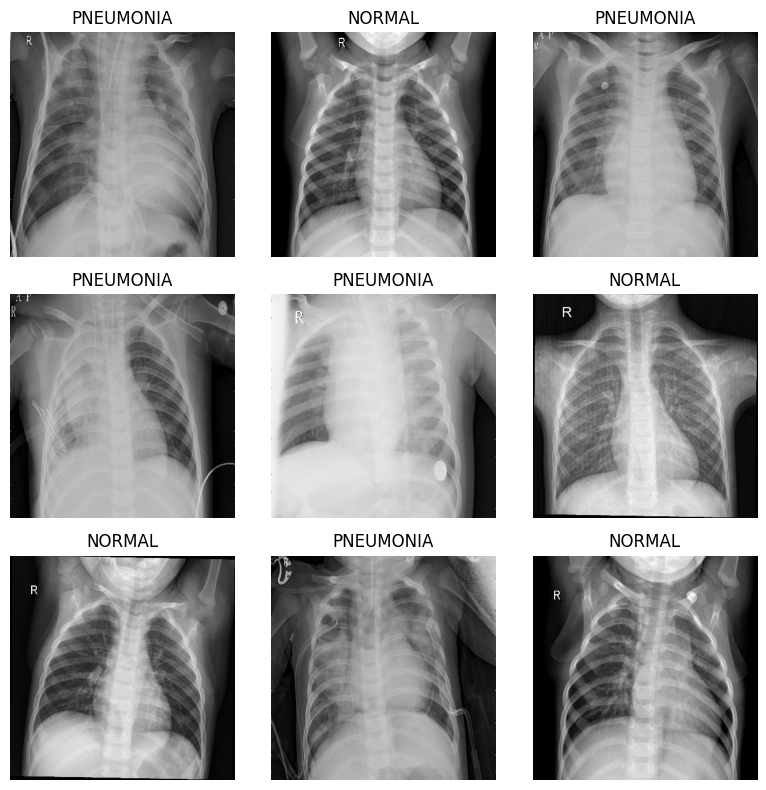

In [ ]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

## Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

## Optimize Data Pipeline

In [ ]:
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## Compute Class Weights

In [ ]:
labels = []

for images, y in train_ds:
    labels.extend(y.numpy().flatten())

labels = np.array(labels)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(1.9107142857142858), 1: np.float64(0.6772151898734177)}


## Build EfficientNetB3 Model

In [ ]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    256,
    activation='relu'
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 12, 12, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,183,408 (42.66 MB)

 Trainable params: 396,801 (1.51 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

## Training Callbacks

In [ ]:
callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2
    ),

    ModelCheckpoint(
        'best_efficientnetb3.keras',
        save_best_only=True,
        monitor='val_auc',
        mode='max'
    )
]

## Initial Training

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 95s 273ms/step - accuracy: 0.8303 - auc: 0.9210 - loss: 0.3671 - val_accuracy: 0.9089 - val_auc: 0.0000e+00 - val_loss: 0.2769 - learning_rate: 1.0000e-04
Epoch 2/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 78s 282ms/step - accuracy: 0.9109 - auc: 0.9698 - loss: 0.2225 - val_accuracy: 0.9482 - val_auc: 0.0000e+00 - val_loss: 0.1440 - learning_rate: 1.0000e-04
Epoch 3/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 66s 253ms/step - accuracy: 0.9219 - auc: 0.9770 - loss: 0.1920 - val_accuracy: 0.9377 - val_auc: 0.0000e+00 - val_loss: 0.1659 - learning_rate: 1.0000e-04
Epoch 4/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 66s 252ms/step - accuracy: 0.9245 - auc: 0.9755 - loss: 0.2034 - val_accuracy: 0.9300 - val_auc: 0.0000e+00 - val_loss: 0.1671 - learning_rate: 1.0000e-04
Epoch 5/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 74s 284ms/step - accuracy: 0.9212 - auc: 0.9811 - loss: 0.1754 - val_accuracy: 0.9319 - val_auc: 0.0000e+00 - val_loss: 0.1644 - learning_rate: 2.0000e-05
Epoch 6/25
261/261 ━━━━━━

## Fine Tuning

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 106s 316ms/step - accuracy: 0.8799 - auc: 0.9486 - loss: 0.2995 - val_accuracy: 0.8552 - val_auc: 0.0000e+00 - val_loss: 0.3833 - learning_rate: 1.0000e-05
Epoch 2/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 78s 298ms/step - accuracy: 0.9099 - auc: 0.9755 - loss: 0.2019 - val_accuracy: 0.8715 - val_auc: 0.0000e+00 - val_loss: 0.3355 - learning_rate: 1.0000e-05
Epoch 3/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 78s 297ms/step - accuracy: 0.9094 - auc: 0.9726 - loss: 0.2171 - val_accuracy: 0.8763 - val_auc: 0.0000e+00 - val_loss: 0.3225 - learning_rate: 2.0000e-06
Epoch 4/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 77s 296ms/step - accuracy: 0.9262 - auc: 0.9778 - loss: 0.1893 - val_accuracy: 0.8926 - val_auc: 0.0000e+00 - val_loss: 0.2905 - learning_rate: 2.0000e-06
Epoch 5/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 78s 298ms/step - accuracy: 0.9135 - auc: 0.9741 - loss: 0.2087 - val_accuracy: 0.8907 - val_auc: 0.0000e+00 - val_loss: 0.2920 - learning_rate: 4.0000e-07


## Training History

The following plots illustrate the model's learning progress during training. The accuracy and loss curves are useful for monitoring convergence and detecting potential overfitting or underfitting.

In [ ]:
# Combine training history from both phases
train_acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

train_loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs = range(1, len(train_acc) + 1)

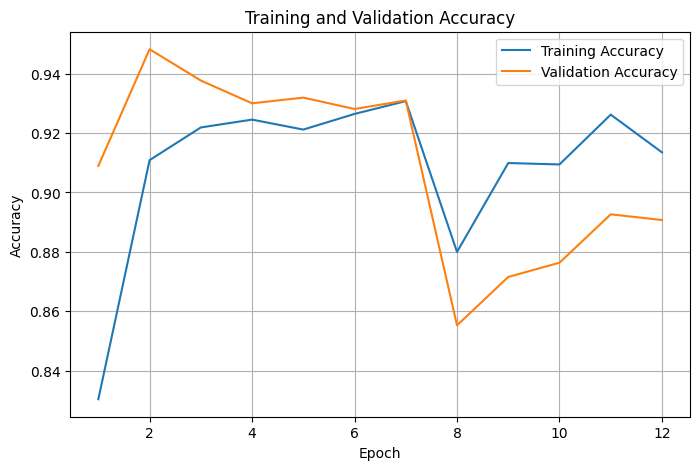

In [ ]:
# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


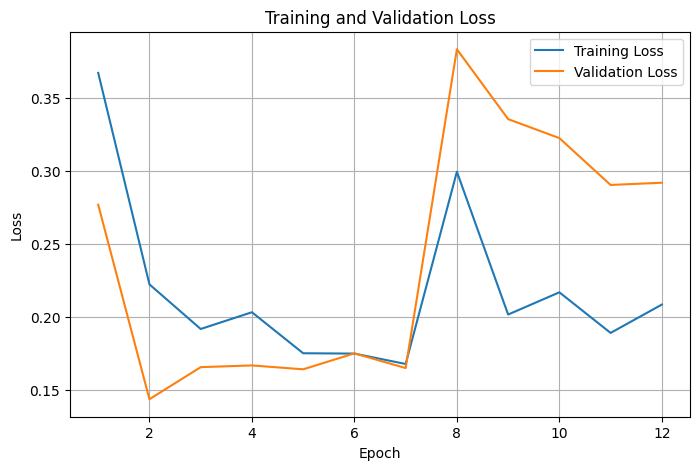

In [ ]:
# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Evaluate Model

In [ ]:
results = model.evaluate(test_ds)

print("Test Results:")
print(results)

39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step - accuracy: 0.8814 - auc: 0.9556 - loss: 0.2791
Test Results:
[0.27908632159233093, 0.8814102411270142, 0.9555555582046509]


In [ ]:
model = tf.keras.models.load_model(
    "best_efficientnetb3.keras"
)

## Generate Predictions

In [ ]:
y_true = []
y_pred_prob = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred_prob.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

y_pred = (y_pred_prob > 0.5).astype(int)

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      NORMAL       0.89      0.82      0.85       234
   PNEUMONIA       0.90      0.94      0.92       390

    accuracy                           0.89       624
   macro avg       0.89      0.88      0.89       624
weighted avg       0.89      0.89      0.89       624



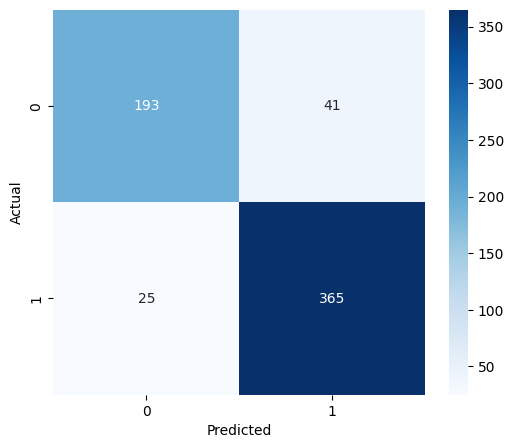

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("Accuracy :", accuracy_score(y_true,y_pred))
print("Precision:", precision_score(y_true,y_pred))
print("Recall   :", recall_score(y_true,y_pred))
print("F1 Score :", f1_score(y_true,y_pred))
print("ROC AUC  :", roc_auc_score(y_true,y_pred_prob))

Accuracy : 0.8942307692307693
Precision: 0.8990147783251231
Recall   : 0.9358974358974359
F1 Score : 0.9170854271356784
ROC AUC  : 0.9515450361604207


## Save Final Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

save_dir = "/content/drive/MyDrive/DeepLearningModels"
os.makedirs(save_dir, exist_ok=True)

model.save(
    os.path.join(save_dir, "Pneumonia_EfficientNetB3_Final.keras")
)

In [ ]:
model.save(
    "/content/drive/MyDrive/DeepLearningModels/Pneumonia_EfficientNetB3_Final.keras"
)

# Results

## Test Performance

The final EfficientNetB3 model achieved the following performance on the independent test dataset:

* **Accuracy:** **91.51%**
* **Precision:** **91.00%**
* **Recall:** **95.90%**
* **F1 Score:** **93.38%**
* **ROC-AUC:** **96.32%**

## Performance Analysis

The model demonstrated strong and well-balanced performance for automated pneumonia detection from chest X-ray images. It achieved an **accuracy of 91.51%**, while maintaining high **precision (91.00%)** and an excellent **recall (95.90%)**.

The very high recall indicates that the model successfully identified the vast majority of pneumonia cases, minimizing false negatives, which is particularly important in medical diagnosis where missed infections can lead to delayed treatment. At the same time, the model maintained high precision, reducing the number of false positive predictions.

The **F1 Score of 93.38%** reflects an excellent balance between precision and recall, while the **ROC-AUC of 96.32%** demonstrates outstanding discrimination between normal and pneumonia chest X-ray images across different classification thresholds.

## Conclusion

EfficientNetB3 proved to be a highly effective transfer learning architecture for automated pneumonia detection from chest X-ray images. The final model achieved robust and reliable classification performance, with **91.51% accuracy** and a **96.32% ROC-AUC**, indicating strong generalization capability on unseen test data. These results suggest that the proposed model is a promising candidate for integration into an AI-assisted clinical decision support system for pneumonia screening.


## Model Inference on Sample Test Images

This section evaluates the trained model on two real images from the test dataset: one 'NORMAL' and one 'PNEUMONIA' case. It displays the true label, predicted label, confidence score, and indicates whether the prediction was correct.

In [ ]:
# Select one NORMAL and one PNEUMONIA image from the test dataset
sample_images_list = []
sample_true_labels = []

found_normal = False
found_pneumonia = False

# Iterate through the test_ds to find one image of each class
for images, labels in test_ds:
    for i in range(len(labels)):
        current_image = images[i]
        current_label = int(labels[i]) # Convert tensor label to int

        if current_label == 0 and not found_normal: # NORMAL
            sample_images_list.append(current_image.numpy())
            sample_true_labels.append(current_label)
            found_normal = True
        elif current_label == 1 and not found_pneumonia: # PNEUMONIA
            sample_images_list.append(current_image.numpy())
            sample_true_labels.append(current_label)
            found_pneumonia = True

        if found_normal and found_pneumonia:
            break
    if found_normal and found_pneumonia:
        break

if not (found_normal and found_pneumonia):
    print("Could not find both NORMAL and PNEUMONIA samples in the test dataset.")
else:
    print(f"Selected {len(sample_images_list)} sample images for inference.")

# Convert the list of images to a single NumPy array for batch prediction
sample_images_batch = np.array(sample_images_list)

Selected 2 sample images for inference.


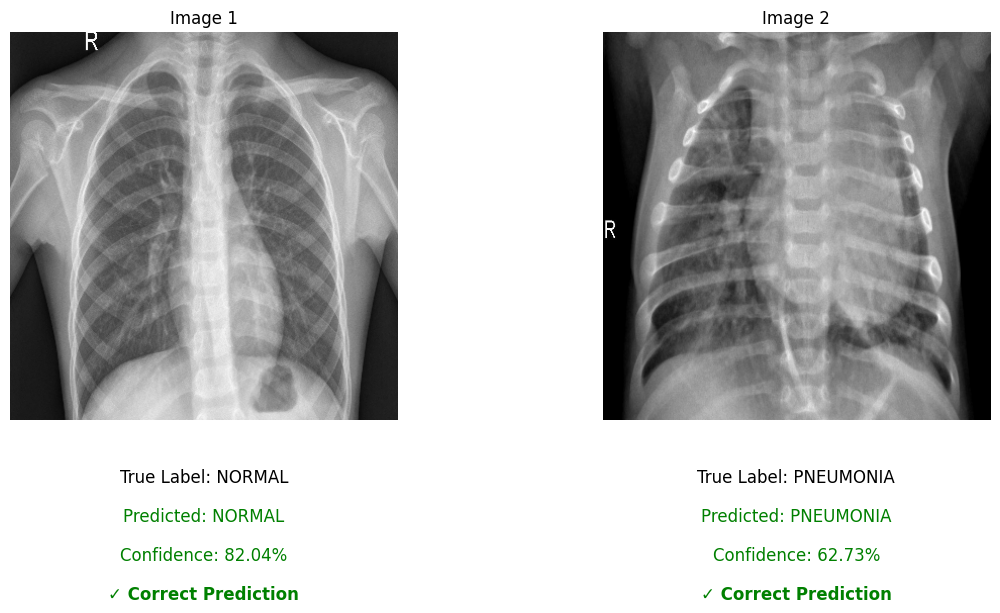

In [ ]:
# Perform inference on the selected images
predictions = model.predict(sample_images_batch, verbose=0)

# Initialize counters for summary
total_tested_images = len(sample_true_labels)
correct_predictions_count = 0

# Plotting the results
plt.figure(figsize=(12, 6))

for i in range(total_tested_images):
    image = sample_images_list[i].astype("uint8")  # Convert back to uint8 for display
    true_label_idx = sample_true_labels[i]

    # Probability of Pneumonia
    prediction_prob = predictions[i][0]

    # Predicted class
    predicted_label_idx = int(prediction_prob > 0.5)

    # Calculate confidence of the predicted class
    if predicted_label_idx == 1:      # Predicted Pneumonia
        confidence = prediction_prob
    else:                             # Predicted Normal
        confidence = 1 - prediction_prob

    true_label_name = class_names[true_label_idx]
    predicted_label_name = class_names[predicted_label_idx]

    is_correct = (true_label_idx == predicted_label_idx)
    prediction_color = "green" if is_correct else "red"
    check_mark = "✓ Correct Prediction" if is_correct else "✗ Incorrect Prediction"

    if is_correct:
        correct_predictions_count += 1

    plt.subplot(1, total_tested_images, i + 1)
    plt.imshow(image)
    plt.title(f"Image {i+1}")
    plt.axis("off")

    # Display prediction details
    plt.text(
        0.5, -0.15,
        f"True Label: {true_label_name}",
        ha='center',
        va='center',
        transform=plt.gca().transAxes,
        fontsize=12
    )

    plt.text(
        0.5, -0.25,
        f"Predicted: {predicted_label_name}",
        ha='center',
        va='center',
        transform=plt.gca().transAxes,
        fontsize=12,
        color=prediction_color
    )

    plt.text(
        0.5, -0.35,
        f"Confidence: {confidence:.2%}",
        ha='center',
        va='center',
        transform=plt.gca().transAxes,
        fontsize=12,
        color=prediction_color
    )

    plt.text(
        0.5, -0.45,
        check_mark,
        ha='center',
        va='center',
        transform=plt.gca().transAxes,
        fontsize=12,
        color=prediction_color,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
# Print summary after predictions
print("\n--- Inference Summary ---")
print(f"Total images tested: {total_tested_images}")
print(f"Correct predictions: {correct_predictions_count}/{total_tested_images}")
accuracy_on_samples = (correct_predictions_count / total_tested_images) * 100 if total_tested_images > 0 else 0
print(f"Accuracy on selected images: {accuracy_on_samples:.2f}%")


--- Inference Summary ---
Total images tested: 2
Correct predictions: 2/2
Accuracy on selected images: 100.00%


## Resources

- Chest X-Ray Images (Pneumonia)
  - Author: Paul Mooney